In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 109.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.54.0
    Uninstalling transformers-4.54.0:
      Successfully uninstalled transformers-4.54.0


In [ ]:
import pandas as pd

df = pd.read_csv("/content/fbdata_labels_final.csv")
df = df[['gemini_cleaned', 'gemini_label']]
df.head()

,gemini_cleaned,gemini_label
0,C'est la vérité.,soutien_appui
1,Effectivement.,neutre
2,Belle remarque.,soutien_appui
3,Absolument vrai.,soutien_appui
4,On rentre dans les calculs comme nous savons b...,autre_superflu


In [ ]:
df = df.drop_duplicates()
df['gemini_label'].value_counts()

,count
gemini_label,
neutre,3053
soutien_appui,2841
moquerie_sarcasme,1069
colère_indignation,968
question_demande_info,914
plainte_revendication,890
joie_positivité,860
autre_superflu,553
politique,545


In [ ]:
df.shape

(13815, 2)

In [ ]:
df.isnull().sum()

,0
gemini_cleaned,2
gemini_label,0


In [ ]:
df = df.dropna()
df.isnull().sum()

,0
gemini_cleaned,0
gemini_label,0


In [ ]:
df['gemini_label'].value_counts()

,count
gemini_label,
neutre,3052
soutien_appui,2841
moquerie_sarcasme,1069
colère_indignation,968
question_demande_info,914
plainte_revendication,890
joie_positivité,860
autre_superflu,552
politique,545


In [ ]:
df['gemini_label'].unique()

array(['soutien_appui', 'neutre', 'autre_superflu',
       'question_demande_info', 'colère_indignation', 'moquerie_sarcasme',
       'récit_narration_faits', 'plainte_revendication', 'politique',
       'profanité_insulte', 'patriotisme_nationalisme', 'joie_positivité',
       'religion', 'humour_blague', 'annonce_event', 'appel_action',
       'peur_inquiétude', 'harcèlement_intimidation',
       'tristesse_détresse', 'critique', 'complot_rumeur_speculation',
       'drogue_alcool', 'haine_racisme', 'publicité_spam ',
       'racisme_xénophobie', 'menace', 'désinformation_fake_manipulation',
       'sexisme_genre', 'motivation', 'paix_unité', 'communauté',
       'diffamation_accusation', 'sexualité_explicite',
       'diffamation_doxxing', 'information', 'urgence_alerte',
       'analyse_critique', 'suggestion', 'insulte', 'alerte_urgence',
       'conseil', 'avertissement', 'publicité_spam'], dtype=object)

In [ ]:
label_counts = df['gemini_label'].value_counts()
labels_to_keep = label_counts[label_counts >= 100].index
df = df[df['gemini_label'].isin(labels_to_keep)]
df['gemini_label'].value_counts()

,count
gemini_label,
neutre,3052
soutien_appui,2841
moquerie_sarcasme,1069
colère_indignation,968
question_demande_info,914
plainte_revendication,890
joie_positivité,860
autre_superflu,552
politique,545


In [ ]:
df['gemini_label'].unique().shape

(14,)

In [ ]:
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    CamembertModel,
    CamembertTokenizer,
    CamembertForSequenceClassification
)

In [ ]:
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['gemini_label'])

label2id = {str(label): int(idx) for label, idx in zip(le.classes_, le.transform(le.classes_))}
id2label = {int(idx): str(label) for label, idx in label2id.items()}

df[['gemini_cleaned', 'gemini_label', 'label_id']].head()

,gemini_cleaned,gemini_label,label_id
0,C'est la vérité.,soutien_appui,13
1,Effectivement.,neutre,5
2,Belle remarque.,soutien_appui,13
3,Absolument vrai.,soutien_appui,13
4,On rentre dans les calculs comme nous savons b...,autre_superflu,0


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['gemini_cleaned'].tolist(),
    df['label_id'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label_id']
)

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Create indices for the training data
train_indices = np.arange(len(train_texts))

# Apply SMOTE on the indices
smote = SMOTE(random_state=42)
train_indices_resampled, train_labels_resampled = smote.fit_resample(train_indices.reshape(-1, 1), train_labels)

# Use the oversampled indices to select the corresponding texts and labels
train_texts_resampled = [train_texts[i] for i in train_indices_resampled.flatten()]

print("Original training data size:", len(train_texts))
print("Resampled training data size:", len(train_texts_resampled))
print("Original training labels size:", len(train_labels))
print("Resampled training labels size:", len(train_labels_resampled))

Original training data size: 10388
Resampled training data size: 34174
Original training labels size: 10388
Resampled training labels size: 34174


In [ ]:
train_texts = train_texts_resampled
train_labels = train_labels_resampled

In [ ]:
from transformers import pipeline

pipe = pipeline("fill-mask", model="almanach/camembert-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of the model checkpoint at almanach/camembert-base were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("almanach/camembert-base")
model = AutoModelForMaskedLM.from_pretrained("almanach/camembert-base")

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

Some weights of the model checkpoint at almanach/camembert-base were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
class FbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = FbDataset(train_encodings, train_labels)
val_dataset = FbDataset(val_encodings, val_labels)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "camembert-base",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    do_eval=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir='./logs',x
    logging_steps=10,
)

In [ ]:
def compute_metrics(p):
    preds = torch.argmax(torch.tensor(p.predictions), axis=1)
    return {
        "precision": precision_score(p.label_ids, preds, average='macro'),
        "recall": recall_score(p.label_ids, preds, average='macro'),
        "f1": f1_score(p.label_ids, preds, average='macro'),
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-4030190838.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sfanta087 (sfanta087-student) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Step,Training Loss
10,2.636100
20,2.650200
30,2.650400
40,2.627300
50,2.647900
60,2.623300
70,2.651700
80,2.628000
90,2.593500
100,2.633100


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
/usr/local/lib/p

TrainOutput(global_step=17088, training_loss=2.401365234275882, metrics={'train_runtime': 7219.9177, 'train_samples_per_second': 18.933, 'train_steps_per_second': 2.367, 'total_flos': 1.7282510876731968e+16, 'train_loss': 2.401365234275882, 'epoch': 4.0})

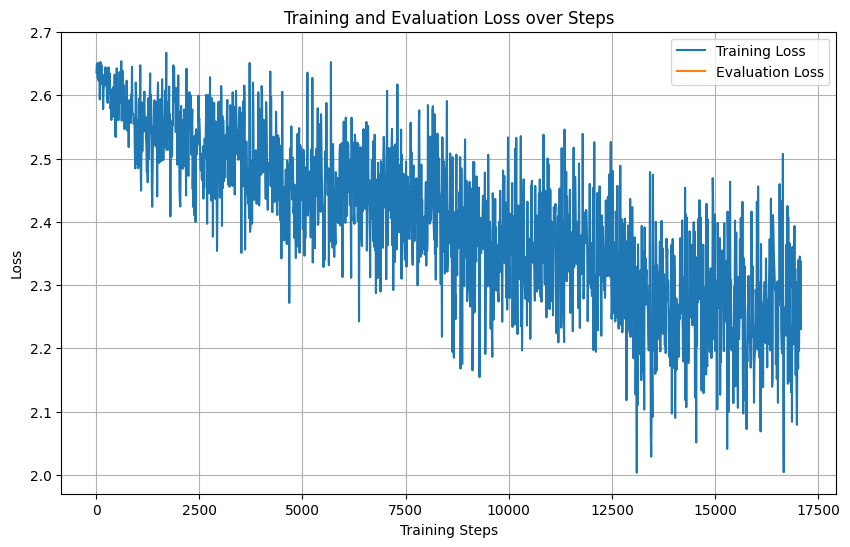

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract loss values from the trainer's log history
log_history = trainer.state.log_history

train_loss = []
eval_loss = []
steps = []

for log in log_history:
    if 'loss' in log:
        train_loss.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log:
        eval_loss.append(log['eval_loss'])


# Create a DataFrame for easier plotting
loss_df = pd.DataFrame({'Training Loss': train_loss, 'Step': steps[:len(train_loss)]})
# Assuming eval_loss logs correspond to the same steps or can be aligned
# This might need adjustment based on how eval_loss is logged
eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
eval_loss_df = pd.DataFrame({'Evaluation Loss': eval_loss, 'Step': eval_steps})


# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(loss_df['Step'], loss_df['Training Loss'], label='Training Loss')
plt.plot(eval_loss_df['Step'], eval_loss_df['Evaluation Loss'], label='Evaluation Loss')
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training and Evaluation Loss over Steps")
plt.legend()
plt.grid(True)
plt.show()

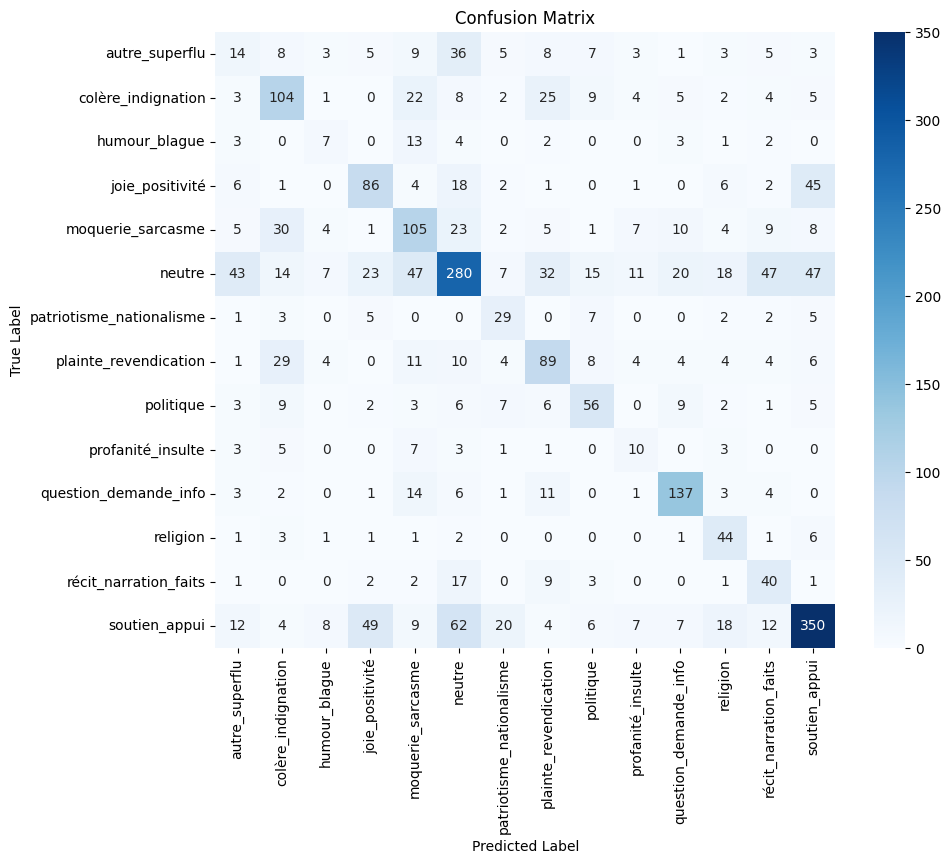

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from the trainer on the validation dataset
predictions = trainer.predict(val_dataset)
predicted_labels_ids = predictions.predictions.argmax(axis=1)

# Get the true labels
true_labels_ids = val_labels

# Calculate the confusion matrix
cm = confusion_matrix(true_labels_ids, predicted_labels_ids)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=id2label.values(), yticklabels=id2label.values())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_true = val_labels
y_pred = predictions.predictions.argmax(axis=1)

print(classification_report(
    y_true,
    y_pred,
    labels=le.transform(le.classes_),
    target_names=le.classes_,
    zero_division=0
))

                          precision    recall  f1-score   support

          autre_superflu       0.14      0.13      0.13       110
      colère_indignation       0.49      0.54      0.51       194
           humour_blague       0.20      0.20      0.20        35
         joie_positivité       0.49      0.50      0.50       172
       moquerie_sarcasme       0.43      0.49      0.46       214
                  neutre       0.59      0.46      0.52       611
patriotisme_nationalisme       0.36      0.54      0.43        54
   plainte_revendication       0.46      0.50      0.48       178
               politique       0.50      0.51      0.51       109
       profanité_insulte       0.21      0.30      0.25        33
   question_demande_info       0.70      0.75      0.72       183
                religion       0.40      0.72      0.51        61
   récit_narration_faits       0.30      0.53      0.38        76
           soutien_appui       0.73      0.62      0.67       568

        

In [ ]:
model_path = "./camembert-finetuned-gemini"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"Modèle et tokenizer sauvegardés dans : {model_path}")

Modèle et tokenizer sauvegardés dans : ./camembert-finetuned-gemini


In [ ]:
import torch
import torch.nn.functional as F

def predict_label(text, show_all_scores=False):
    device = model.device

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    outputs = model(**inputs)
    logits = outputs.logits

    probs = F.softmax(logits, dim=1)

    predicted_class_idx = torch.argmax(probs, dim=1).item()
    predicted_label = id2label[predicted_class_idx]
    confidence = probs[0, predicted_class_idx].item()

    if show_all_scores:
        print("Scores pour chaque classe :")
        for idx, score in enumerate(probs[0]):
            label = id2label[idx]
            print(f"  {label:<25} : {score.item():.4f}")

    return predicted_label, confidence

textes_exemple = val_texts[:10]
labels_exemple = val_labels[:10]

print("Predictions on Example Validation Data:")
for i, t in enumerate(textes_exemple):
    real_label = id2label[labels_exemple[i]]
    predicted_label, confidence = predict_label(t)
    print(f"\"{t}\" → Real: {real_label}, Predicted: {predicted_label} (confiance : {confidence:.2%})\n")

Predictions on Example Validation Data:
"Traoré." → Real: neutre, Predicted: neutre (confiance : 18.60%)

"Bonne fête" → Real: soutien_appui, Predicted: joie_positivité (confiance : 47.74%)

"Est-ce vous qui leur avez dit de quitter la CEDEAO? Toute chose vient à point nommé qui sait attendre." → Real: question_demande_info, Predicted: neutre (confiance : 26.15%)

"Quand je me rappelle que c'est RFI, j'écoutais et dormais avec l'écouteur aux oreilles, j'ai envie vraiment de vomir." → Real: colère_indignation, Predicted: récit_narration_faits (confiance : 23.38%)

"C'est donc à moi qu'il faut demander. Effet d'amour." → Real: moquerie_sarcasme, Predicted: patriotisme_nationalisme (confiance : 14.59%)

"Cette fois-ci on ne voit pas tes dents dehors. Pour la première fois." → Real: neutre, Predicted: moquerie_sarcasme (confiance : 37.08%)

"Je ne pourrais jamais te pardonner ça." → Real: colère_indignation, Predicted: colère_indignation (confiance : 48.96%)



/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


"S'il vous plaît, mettez du sérieux dans vos affiches. Cela ne fait pas sérieux du tout, encore moins à l'échelle d'une fédération nationale de football." → Real: plainte_revendication, Predicted: plainte_revendication (confiance : 49.76%)

"Vous ne verrez jamais cela sur ces médias, ils souhaitaient le contraire." → Real: colère_indignation, Predicted: colère_indignation (confiance : 32.01%)

"Et puis voilà elle a eu son contraceptif naturel comme ça hein tu fais enfant quand tu veux. Dieu il est fort way" → Real: religion, Predicted: moquerie_sarcasme (confiance : 19.69%)



In [ ]:
import shutil
import os
from google.colab import files

# Define the path to the saved model directory
model_path = "./camembert-finetuned-gemini"
zip_path = "./camembert-finetuned-gemini.zip"

# Create a zip archive of the directory
shutil.make_archive(model_path, 'zip', model_path)

# Provide a download link for the zip file
print(f"Le modèle et le tokenizer ont été zippés dans : {zip_path}")
files.download(zip_path)

Le modèle et le tokenizer ont été zippés dans : ./camembert-finetuned-gemini.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile
import os

# Nom du dossier de destination
dossier_destination = "camembert_finetuned"

# Créer le dossier s'il n'existe pas
os.makedirs(dossier_destination, exist_ok=True)

# Chemin du fichier zip
zip_path = "./camembert-finetuned-gemini.zip"

# Dézipper dans le dossier créé
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dossier_destination)

print(f"Le fichier {zip_path} a été dézippé dans {dossier_destination}.")


Le fichier ./camembert-finetuned-gemini.zip a été dézippé dans camembert_finetuned.


In [ ]:
from transformers import CamembertTokenizer, CamembertModel
import torch
from sklearn.metrics.pairwise import cosine_similarity

# Chemin vers ton modèle dézippé
model_path = "./camembert_finetuned"

tokenizer = CamembertTokenizer.from_pretrained(model_path)
model = CamembertModel.from_pretrained(model_path)


Some weights of CamembertModel were not initialized from the model checkpoint at ./camembert_finetuned and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # On utilise la moyenne des embeddings des tokens
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()


In [ ]:
texte = "Bonne fête"
classes = [
    "neutre",
    "soutien_appui",
    "moquerie_sarcasme",
    "colère_indignation",
    "question_demande_info",
    "plainte_revendication",
    "joie_positivité",
    "autre_superflu",
    "politique",
    "récit_narration_faits",
    "religion",
    "patriotisme_nationalisme",
    "humour_blague",
    "profanité_insulte"
]



In [ ]:
# Générer les embeddings
embedding_texte = get_embedding(texte)
embeddings_classes = [get_embedding(cls) for cls in classes]

# Calculer les similarités cosinus
similarites = cosine_similarity([embedding_texte], embeddings_classes)[0]

# Trouver la classe la plus proche
classe_predite = classes[similarites.argmax()]
print(f"Classe prédite : {classe_predite}")
print(f"Scores : {dict(zip(classes, similarites))}")


Classe prédite : joie_positivité
Scores : {'neutre': np.float32(0.29286057), 'soutien_appui': np.float32(0.0803517), 'moquerie_sarcasme': np.float32(0.24291268), 'colère_indignation': np.float32(0.30267674), 'question_demande_info': np.float32(0.23989898), 'plainte_revendication': np.float32(0.28988817), 'joie_positivité': np.float32(0.9545231), 'autre_superflu': np.float32(0.37152314), 'politique': np.float32(0.20001525), 'récit_narration_faits': np.float32(0.15117651), 'religion': np.float32(0.26826444), 'patriotisme_nationalisme': np.float32(0.22075538), 'humour_blague': np.float32(0.2598946), 'profanité_insulte': np.float32(0.37703457)}
